# Modular pipeline: specimen placement → ice → tilt-coverage padding → per-tilt scattering → optics → detector

The other tilt-series notebook (`create_tilt_series/`) goes through `TiltSeriesGenerator`:
one class that blends ice into a pre-assembled specimen volume, pads it in XY for the
requested tilt range, and drives `IterativeScattering` → `Aberration` → `Detector` once
per tilt angle from `generate_tilt_series()`.

This notebook builds the **same physical pipeline by hand**, one stage per section,
calling each module directly instead of going through `TiltSeriesGenerator`. Specimen
placement itself is already exposed as a standalone piece --
`specter.pipelines.build_tomogram_generator` (the same code behind `specter build
tomogram`) -- and is used identically in both notebooks; the "modular" part here is what
`TiltSeriesGenerator` does internally with that assembled volume (see
`create_particle_stack_modular/` for the equivalent breakdown of `ImageGenerator`, the
single-particle counterpart).

Pipeline (mirrors `TiltSeriesGenerator.__init__`/`generate_tilt_series` in
`imagegenerator/_tiltseries.py`, stage for stage):

```
targets/filler/membrane
  └─ placed specimen volume           (specter.pipelines.build_tomogram_generator)
      └─ + amorphous ice               (specter.ice: resolve_icemaker / blend_ice_into_volume)
          └─ padded for tilt coverage   (TiltSeriesGenerator's own geometry helpers)
              └─ per tilt angle:
                  ├─ affine pose                    (specter.rotations)
                  ├─ rotate + multislice, fused     (specter.scattering.IterativeScattering)
                  ├─ aberrated exit wave            (specter.aberrations.Aberration)
                  └─ detector image                 (specter.microscope.Detector)
```

Two config files drive this notebook: [`tomogram.toml`](./tomogram.toml) (specimen
composition, box size) and
[`tilt_series_generator_modular.toml`](./tilt_series_generator_modular.toml) (tilt range,
defocus, and everything downstream), both loaded below via `load_config`. Edit those
files, not this notebook, to change what gets generated -- the one exception is
`tilt_series_generator_modular.toml`'s own `voxel_size`, synced automatically from
`tomogram.toml`'s `voxel_size` right after loading (see below) instead of needing to be
hand-matched across both files.

In [1]:
import logging
import time

import matplotlib.pyplot as plt
import roma
import torch

import specter
from specter import rotations
from specter.config import load_config, TiltSeriesConfig, TomogramConfig
from specter.plots import plot_particle_stack, plot3d
from specter.pipelines import build_tomogram_generator
from specter.ice import resolve_icemaker, blend_ice_into_volume
from specter.scattering import IterativeScattering
from specter.aberrations import (
    Aberration,
    aberration_model_for_scattering,
    defocus_midplane_shift,
)
from specter.microscope import Detector
from specter import tilt as tilt_geometry

%load_ext autoreload
%autoreload 2

## Point to Monomers library

In [2]:
tomogram_config = load_config("tomogram.toml", TomogramConfig)
config = load_config("tilt_series_generator_modular.toml", TiltSeriesConfig)

## Voxel size sync

`tilt_series_generator_modular.toml`'s own `voxel_size` MUST equal `tomogram.toml`'s
`voxel_size`: `IterativeScattering`/`Aberration`/`Detector` below all index `vol` at that
spacing, so a mismatch would silently misinterpret the volume's own scale. Read it
directly off `tomogram_config` here instead of hand-syncing two TOML files.

In [3]:
# tilt_series_generator_modular.toml's voxel_size must match tomogram.toml's
# voxel_size; read it off tomogram_config directly instead of hand-syncing both files.
config.voxel_size = tomogram_config.voxel_size
config.voxel_size

10.0

In [4]:
specter.set_verbosity(logging.INFO)
device = config.device
device

'cuda:0'

## 1. Specimen placement

`build_tomogram_generator` runs RSA hard-sphere packing (targets/filler, region-gated to
cytosol/lumen when a membrane is present) plus any organic membrane, then renders every
placed instance's real scattering potential directly. This step is identical to what
`TiltSeriesGenerator`'s caller does in `create_tilt_series/` -- it's already a
standalone, reusable object, no changes needed here.

The summary printed below reuses `specter.pipelines._tomogram`'s own post-generation report (species/membrane/filament/bead counts, occupancy, elapsed time) instead of reimplementing it -- identical to what `specter build tomogram` itself prints for the same config, by construction.

In [5]:
from specter.pipelines._common import _console, _format_elapsed, _section

_section("Building specimen volume")
target_shape = tuple(tomogram_config.target_shape)
size_angstrom = tuple(s * tomogram_config.voxel_size for s in target_shape)
_console.print(
    f"[bold]Volume:[/bold] {target_shape} voxels (Z, Y, X) @ "
    f"{tomogram_config.voxel_size:.2f} A/voxel = {size_angstrom[0]:.0f} x "
    f"{size_angstrom[1]:.0f} x {size_angstrom[2]:.0f} A"
)

t0 = time.perf_counter()
gen = build_tomogram_generator(tomogram_config)
volume = gen.generate()

if gen.membrane_instances:
    _console.print(f"  Membrane instances: {len(gen.membrane_instances)}")
    _console.print(f"  Transmembrane: {len(gen.transmembrane_placements)} placed")
if gen.filament_specs:
    _console.print(
        f"  Filaments: {len(gen.filament_instances)} "
        f"monomer instance(s) placed ({len(gen.filament_specs)} species)"
    )
if gen.carbon_film_spec is not None:
    _console.print("  Carbon film: generated")
if gen.bead_specs:
    n_requested = sum(spec.count for spec in gen.bead_specs)
    _console.print(
        f"  Gold fiducial beads: {len(gen.bead_instances)}/{n_requested} placed"
    )
for location in ("cytosol", "lumen"):
    placed_here = [p for p in gen.placements if p.location == location]
    if not placed_here:
        continue
    n_target = sum(1 for p in placed_here if p.role == "target")
    n_filler = len(placed_here) - n_target
    _console.print(
        f"  {location.capitalize()}: {n_target} target(s), {n_filler} filler placed"
    )
assert gen.instance_labels is not None
occupancy_fraction = float((gen.instance_labels > 0).float().mean())
_console.print(f"  Occupancy: {occupancy_fraction:.1%} of volume")

_console.print(
    f"\n[bold]Total time:[/bold] {_format_elapsed(time.perf_counter() - t0)}"
)

tuple(volume.shape)

──────────────────────────────────────────── Building specimen volume ─────────────────────────────────────────────

Volume: (128, 256, 256) voxels (Z, Y, X) @ 10.00 A/voxel = 1280 x 2560 x 2560 A

/mnt/cbis/home/e0788253/czii/specter/src/specter/potential/_potential_builder.py:310: UserWarning: Some atoms had no matching Shtyrov species and fall back to gemmi's built-in Peng et al. scattering factors. The usual cause is incomplete bond typing, most often a missing Monomer Library (see PDB's monomer_library_path). Reported once per process; for per-structure atom counts and elements, call specter.set_verbosity(logging.DEBUG).
  self._get_3d_shtyrov_species_potentials()


Device: cuda

──────────────────────────────────────────────────── Membranes ────────────────────────────────────────────────────

...

Gold fiducial beads: 5/5 placed

Cytosol: 90 target(s), 2448 filler placed

Occupancy: 45.1% of volume

Total time: 1m 18s

(128, 256, 256)

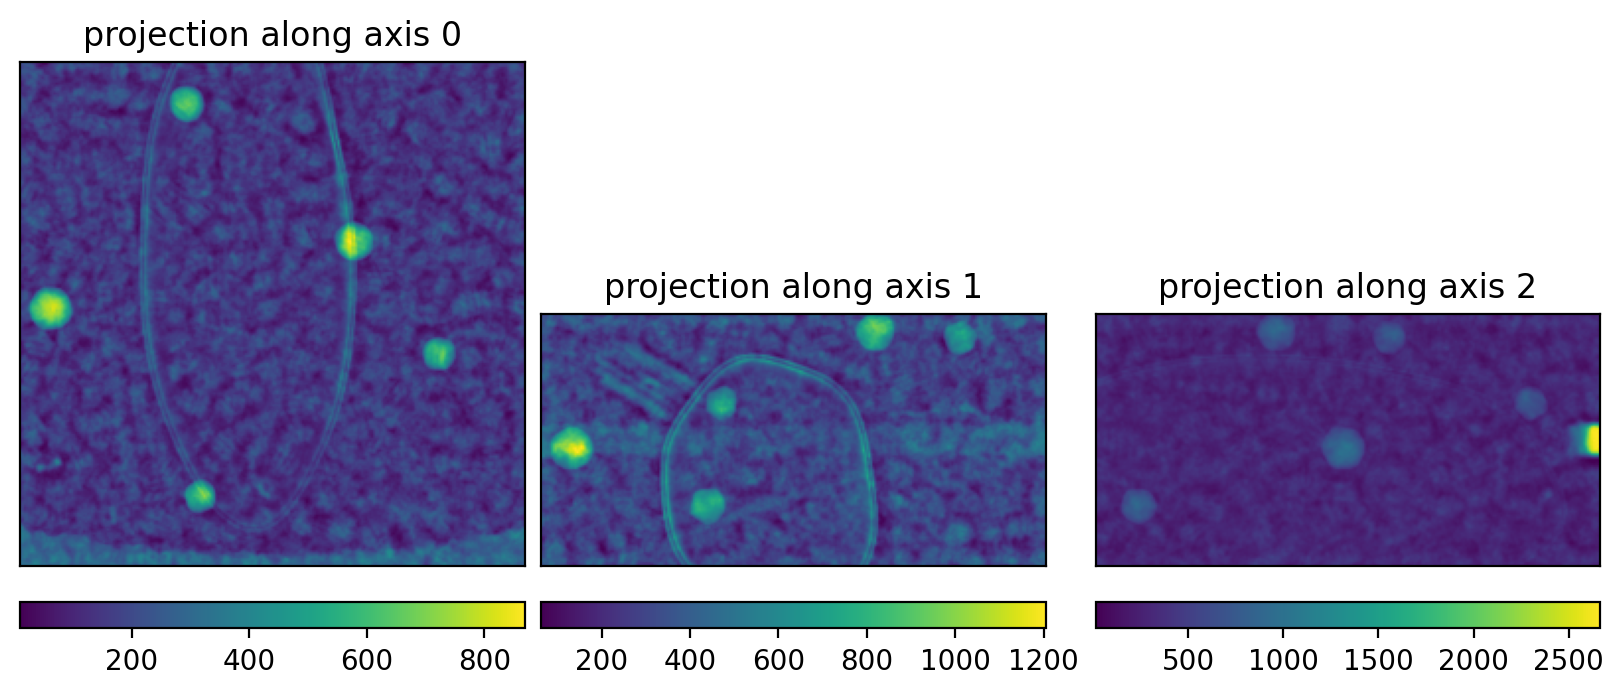

In [6]:
plot3d(volume.cpu())

## 2. Amorphous ice solvation

Ice is added only where the structure itself has little density. `resolve_icemaker`
turns the `ice_model` string into a concrete `IceBank`/`RandomIcemaker` -- the same
helper `TiltSeriesGenerator.__init__` calls internally on its `vol` argument, before any
of its own tilt-coverage padding -- and `blend_ice_into_volume` masks and adds the ice.
Both live in `specter.ice` and have no dependency on `TiltSeriesGenerator` at all, so
they're called here exactly as-is, directly on the assembled `volume` (reshaped to the
`(1, Z, Y, X)` shape the tilt-series pipeline expects).

`ice_model="gd"` samples from the bundled `IceBank` cache (`ice-data/ice_cache`) --
physically relaxed, the realistic option; `"random"` is an instant, cheap placeholder
with no real structure, useful only for quick smoke tests.


In [7]:
vol = volume.unsqueeze(0)  # (1, Z, Y, X), TiltSeriesGenerator's expected shape

ice_model = None if config.ice_model == "none" else config.ice_model

icemaker = resolve_icemaker(
    ice_model,
    config.voxel_size,
    nxy=vol.shape[-1],
    nz=vol.shape[-3],
    ice_cache_dir=config.ice_cache_dir,
)

if icemaker is not None:
    with torch.no_grad():
        vol = blend_ice_into_volume(
            vol, icemaker, config.voxel_size, relax_steps=config.ice_relax_steps
        )

vol.shape

Placing ice tiles:   0%|          | 0/500 [00:00<?, ?it/s]

torch.Size([1, 128, 256, 256])

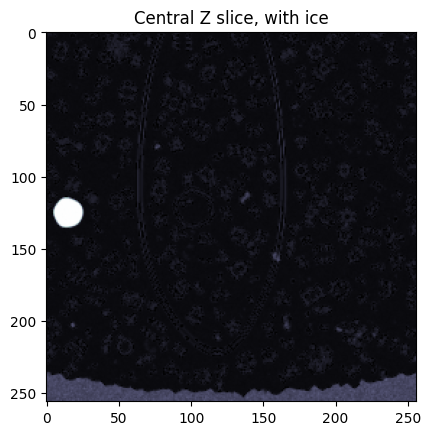

In [8]:
plt.imshow(vol[0, vol.shape[1] // 2].cpu(), cmap="bone")
plt.title("Central Z slice, with ice")
plt.show()

## 3. Padding for tilt coverage

At high tilt, a tilted projection samples XY pixels that fall outside the volume's
original footprint unless the volume is padded first. `specter.tilt` provides the
plain functions `TiltSeriesGenerator` itself calls internally for this -- pure
functions of shape/pose with no generator instance state, so they're reusable
standalone here too:

- `tilt_geometry.estimate_required_nxy`: the minimum XY size so the tilted projection still
  covers the requested output (`micrograph_size`) at the widest tilt angle.
- `tilt_geometry.pad_vol_xy_for_tilt`: reflect-pads symmetrically to that size -- reflect, not
  zero, is correct here because a cryo-ET sample continues physically past any crop in XY
  (unlike Z, which really is bounded by vacuum).

`edge_margin` (8 px, `TiltSeriesGenerator`'s own default) adds a small interpolation-slack
margin on top of the exact geometric minimum -- see the class's docstring for why the
geometric minimum alone leaves zero slack for edge pixels.


In [9]:
micrograph_size = (
    config.micrograph_size if config.micrograph_size is not None else int(vol.shape[-1])
)
edge_margin = 8  # TiltSeriesGenerator's own default

max_tilt_angle_deg = max(abs(config.min_tilt_angle), abs(config.max_tilt_angle))
nz_input, available_nxy = vol.shape[-3], vol.shape[-1]

required_nxy = tilt_geometry.estimate_required_nxy(
    desired_nxy=micrograph_size, nz=nz_input, max_tilt_angle_deg=max_tilt_angle_deg
)
required_nxy_padded = required_nxy + 2 * edge_margin

if available_nxy < required_nxy_padded:
    vol = tilt_geometry.pad_volume_xy_for_tilt(vol, required_nxy_padded, available_nxy)
    print(f"padded (reflect) from {available_nxy} to {vol.shape[-1]} px in XY")

micrograph_size, vol.shape

padded (reflect) from 256 to 508 px in XY


(256, torch.Size([1, 128, 508, 508]))

## 4. Pose sampling: tilt angles → affine matrices

`TiltSeriesGenerator.__init__` converts `angles` into quaternions internally
(`roma.rotvec_to_unitquat`, then `roma.unitquat_to_rotmat` per tilt in
`generate_tilt_series`) so it has one uniform pose representation regardless of
whether the caller passed `angles=` or an arbitrary `quaternions=` directly. We
don't need that generality here -- a tilt series is nothing more than a plain
rotation about one fixed axis (`tilt_axis`, `'x'` or `'y'`), so we skip the
quaternion intermediate and go straight from rotation vector to rotation matrix
via `roma.rotvec_to_rotmat` (verified numerically identical to the quaternion
round-trip, to float32 precision) -- no need to hand-build `Rx`/`Ry` either,
`roma` already has this.

Translations still go through `specter.rotations`' helpers (`build_affine_matrix`,
`translations_angstrom_to_torch`) -- same ones the particle-stack notebook uses for
random poses. Note the normalization size passed to `translations_angstrom_to_torch`
is `vol`'s own (now tilt-coverage-padded) XY extent, not `micrograph_size` -- the
affine grid is defined relative to the volume actually being sampled.


In [10]:
angles = torch.linspace(config.min_tilt_angle, config.max_tilt_angle, config.n_tilts)
n_tilts = len(angles)

theta_rad = torch.deg2rad(angles)
zeros = torch.zeros_like(theta_rad)
if config.tilt_axis == "x":
    rotvecs = torch.stack([theta_rad, zeros, zeros], dim=-1)
else:  # "y"
    rotvecs = torch.stack([zeros, theta_rad, zeros], dim=-1)

R = roma.rotvec_to_rotmat(rotvecs)  # (n_tilts, 3, 3) -- no quaternion needed

translations = torch.zeros(n_tilts, 2)  # no per-tilt shift in this notebook
T = rotations.translations_angstrom_to_torch(
    translations, vol.shape[-1], config.voxel_size
)
thetas = rotations.build_affine_matrix(R, T)  # (n_tilts, 3, 4)

angles

tensor([-45.,   0.,  45.])

## 5. Electron scattering: rotate + multislice, fused

Unlike the particle-stack notebook's `VolumeRotator` + `Scattering` pair (materialize a
rotated copy of the *whole* volume, then propagate it), `IterativeScattering` fuses both
steps: for each pose it samples the rotated volume's slices on the fly as multislice
steps through Z, so the full-resolution rotated volume never has to be materialized in
memory. That difference is what makes tilt-series-scale volumes (hundreds of Z slices,
thousands of pixels per side) tractable at all.

`IterativeScattering` is built at `micrograph_size` -- the desired *output* size -- while
`vol` is the larger, tilt-coverage-padded volume from section 3; its `forward()` samples
an `micrograph_size`-sized ROI out of that larger volume for each pose, exactly as
`TiltSeriesGenerator.generate_tilt_series` calls it per tilt.


In [11]:
vol = vol.to(device)

scattering = IterativeScattering(
    micrograph_size,
    config.voxel_size,
    config.voltage,
    scattering_model=config.scattering_model,
    alpha=config.alpha,
    pad_fft=config.pad_fft,
    roi_padding_mode="zeros",
    progressbars=False,
).to(device)

exitwaves = []
with torch.no_grad():
    for i in range(n_tilts):
        theta = thetas[i : i + 1].to(device)
        exitwaves.append(scattering(vol, theta))

exitwaves = torch.cat(exitwaves, dim=0)
exitwaves.shape, exitwaves.dtype

(torch.Size([3, 256, 256]), torch.complex64)

## 6. Microscope optics: per-tilt defocus correction

Two defocus corrections stack here, both needed because multislice evaluates the exit
wave's phase at the volume's *midplane* while `dfu` follows the CryoSPARC/RELION
entry-face convention:

1. `defocus_midplane_shift` -- the same nominal, untilted correction the particle-stack
   notebook uses.
2. A *per-tilt* correction on top: a tilted sample's Z-extent, as the beam actually sees
   it, grows with tilt angle. `tilt_geometry.nz_tilt_for_pose` (a plain function, like
   `estimate_required_nxy`/`pad_vol_xy_for_tilt` in section 3) computes that rotated
   bounding-box depth per pose -- this part is a genuine per-tilt geometry difference,
   not a coding artifact, so it stays a small loop below. (`TiltSeriesGenerator`'s own
   `generate_tilt_series` computes the same correction per tilt via
   `tilt_geometry.shift_ctf_defocus_for_tilt`, which wraps `nz_tilt_for_pose`.)

`Aberration` itself, though, doesn't need calling per tilt -- like the particle-stack
notebook's own single batched call, it broadcasts over a whole batch of per-item
`cs`/`dfu` in one shot. So the loop below only computes each tilt's own `dfu`
(cheap -- no tensor math beyond `nz_tilt_for_pose`), and `aberration(...)` is called
exactly once, over all tilts at once, afterward.


In [12]:
Cs_A = config.cs * 1e7  # mm -> Å
cc_A = config.cc * 1e7 if config.cc is not None else None
defocus_shift_A = defocus_midplane_shift(vol.shape[-3], config.voxel_size)

# Not user-configurable independently of scattering_model -- see
# aberrations.aberration_model_for_scattering.
aberration_model = aberration_model_for_scattering(config.scattering_model)

aberration = Aberration(
    micrograph_size,
    config.voxel_size,
    config.voltage,
    aberration_model=aberration_model,
    alpha=config.alpha,
    convergence_angle=config.convergence_angle,
    cc=cc_A,
    energy_spread=config.energy_spread,
    deltaV_V=config.deltaV_V,
    deltaI_I=config.deltaI_I,
    dose_envelope=config.dose_envelope,
).to(device)

# Each tilt's rotated Z-extent -- and thus its own midplane defocus shift -- genuinely
# differs with tilt angle, so dfu has to be computed one tilt at a time.
dfu = torch.empty(n_tilts)
for i in range(n_tilts):
    theta = thetas[i : i + 1].to(device)
    nz_tilt = (
        tilt_geometry.nz_tilt_for_pose(tuple(vol.shape), theta)
        if config.scattering_model not in ["projection", "ctf"]
        else vol.shape[-3]
    )
    z_offset = (nz_tilt - vol.shape[-3]) * config.voxel_size / 2.0
    dfu[i] = config.defocus - defocus_shift_A - z_offset

ctf_params = {
    "cs": torch.full((n_tilts,), Cs_A, device=device),
    "dfu": dfu.to(device),
    "dose": torch.full((n_tilts,), config.dose_per_tilt, device=device),
}

with torch.no_grad():
    detector_waves = aberration(exitwaves, ctf_params)  # one call, all tilts at once

detector_waves.shape

torch.Size([3, 256, 256])

## 7. Detector

`Detector` converts the aberrated exit wave to an intensity image, applying dose
scaling, optional MTF, and Poisson noise. `dose_per_tilt`/`coincidence_radius` don't
vary across tilts in this notebook, so -- like `aberration` above -- it's called once
over the whole batch of tilts rather than once per tilt.


In [13]:
noise_model = None if config.noise_model == "none" else config.noise_model

detector = Detector(
    config.voxel_size,
    aberration_model=aberration_model,
    noise_model=noise_model,
    mtf=None,  # config.detector_model == "none"; swap in specter.detectors.k3_300kv(...) etc. otherwise
    n_frames=config.n_frames,
).to(device)

dose_batch = torch.full((n_tilts,), config.dose_per_tilt, device=device)
coincidence_radius = torch.full((n_tilts,), config.coincidence_radius, device=device)

with torch.no_grad():
    tilt_series = detector(detector_waves, dose_batch, coincidence_radius, nxy=None)

tilt_series = tilt_series.detach().cpu()
tilt_series.shape

torch.Size([3, 256, 256])

## 8. Visualize the tilt series


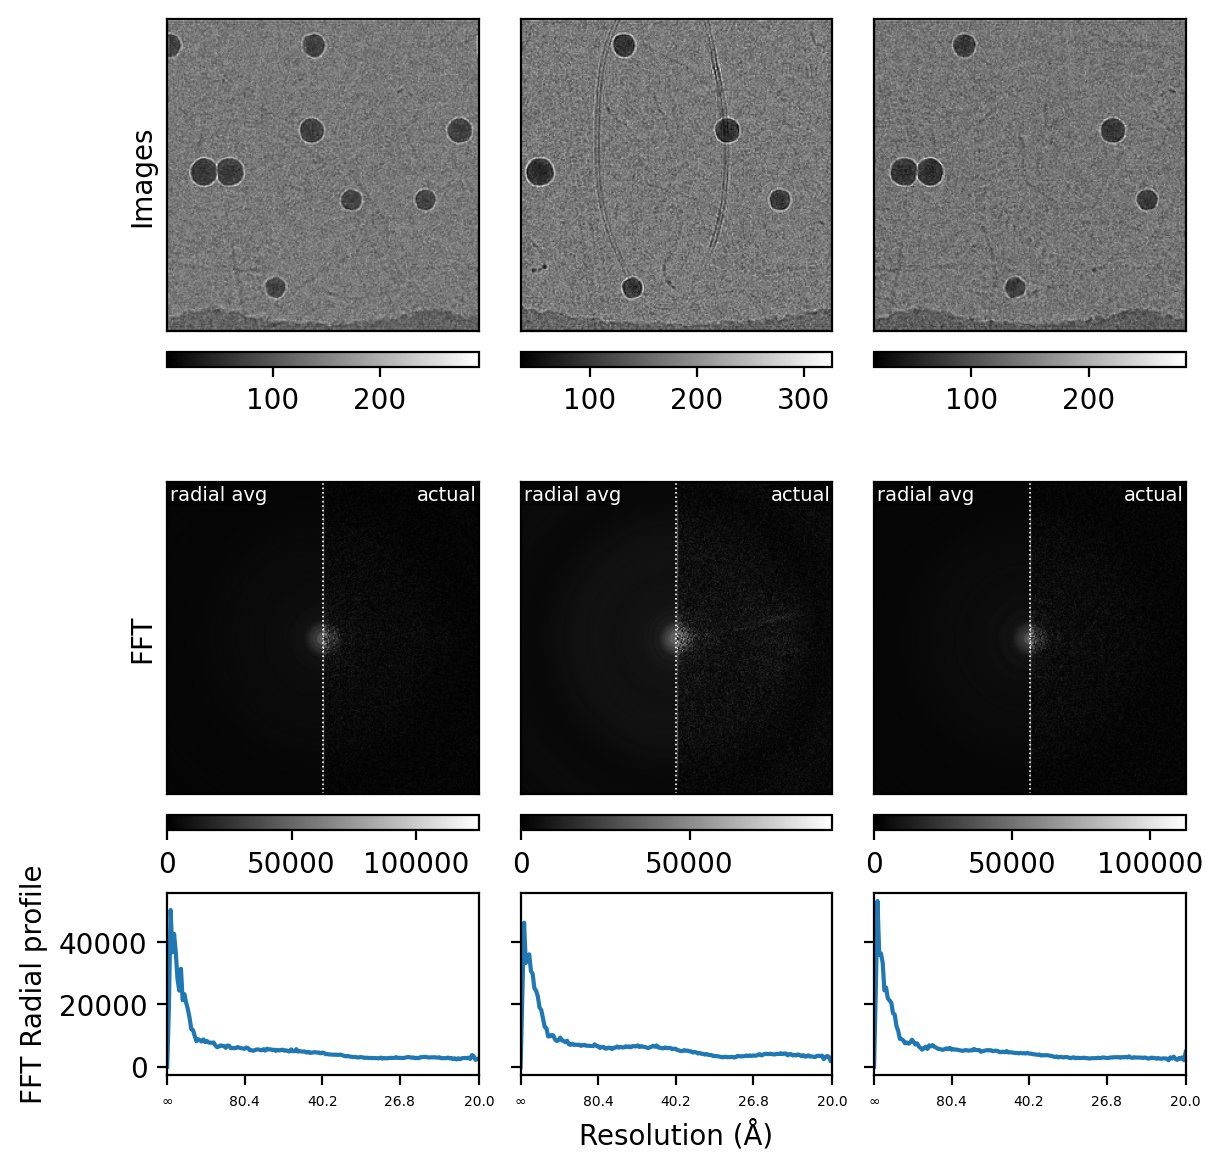

In [14]:
plot_particle_stack(tilt_series, config.voxel_size)